In [1]:
import pandas as pd
import ast
import matplotlib.pyplot as plt
from datasets import load_dataset

# Loading Data
dataset = load_dataset(
    'lukebarousse/data_jobs',
    split='train'
)

# Convert to Pandas
df = dataset.to_pandas()

# Data Cleanup
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

print("Data loaded successfully!")
print(df.shape)

Data loaded successfully!
(785741, 17)


In [2]:
# Only get data analyst jobs 
df_DA_US = df[(df['job_title_short'] == 'Data Analyst') & (df['job_country'] == 'United States')].copy()

# Drop NaN values from the column for plotting
df_DA_US = df_DA_US.dropna(subset=['salary_year_avg'])

df_DA_US['salary_year_avg'].sample(10)

364933    102500.0
436538     79500.0
502106    125000.0
321617     62500.0
235715    157500.0
139776     84800.0
237051    100000.0
248289     90000.0
126321     82350.5
775516     80000.0
Name: salary_year_avg, dtype: float64

<Axes: >

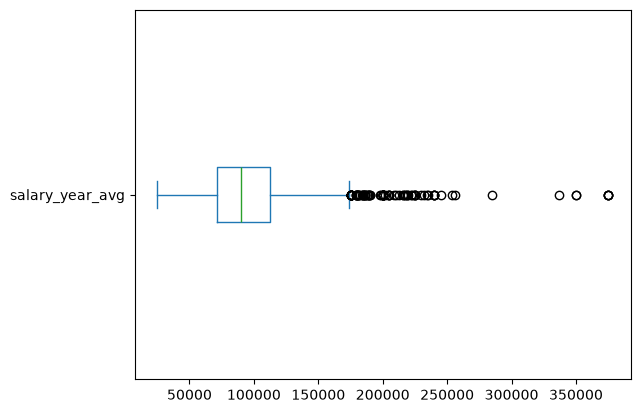

In [6]:
df_DA_US['salary_year_avg'].plot(kind='box', vert= False)

{'whiskers': [<matplotlib.lines.Line2D at 0x25e3f1081a0>,
 'caps': [<matplotlib.lines.Line2D at 0x25e3f108440>,
 'boxes': [<matplotlib.lines.Line2D at 0x25e3f108050>],
 'medians': [<matplotlib.lines.Line2D at 0x25e3f1086e0>],
 'fliers': [<matplotlib.lines.Line2D at 0x25e3f108830>],
 'means': []}

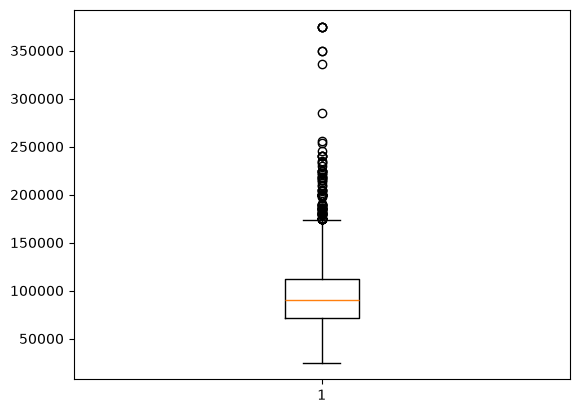

In [7]:
plt.boxplot(df_DA_US['salary_year_avg'])

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_6264\3816015585.py:10: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(job_list, tick_labels=job_titles, vert=False)


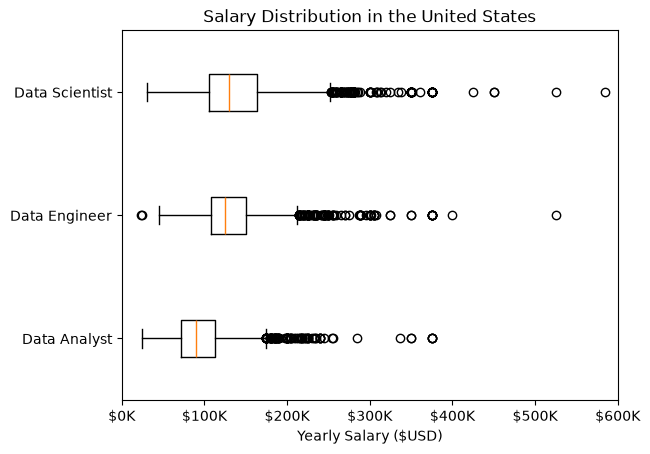

In [22]:
job_titles = ['Data Analyst', 'Data Engineer', 'Data Scientist']

# filter for the job titles and country
df_US = df[(df['job_title_short'].isin(job_titles)) & (df['job_country'] == 'United States')].dropna(subset=['salary_year_avg'])
df_US = df_US.dropna(subset=['salary_year_avg'])

# list of salaries for each job title
job_list = [df_US[df_US['job_title_short'] == job_title]['salary_year_avg'] for job_title in job_titles]

plt.boxplot(job_list, tick_labels=job_titles, vert=False)
plt.title('Salary Distribution in the United States')
plt.xlabel('Yearly Salary ($USD)')
ax = plt.gca()
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, pos: f'${int(x/1000)}K'))
plt.xlim(0,600000)
plt.show()

In [9]:
df_US['job_title_short'].value_counts()

job_title_short
Data Scientist    4553
Data Analyst      4350
Data Engineer     2915
Name: count, dtype: int64

In [11]:
df_US['salary_year_avg']

92        120000.0
100       228222.0
109        89000.0
116       114000.0
146       129500.0
            ...   
785563    136400.0
785624    139216.0
785641    150000.0
785648    221875.0
785692    157500.0
Name: salary_year_avg, Length: 11818, dtype: float64